# AOMIC-ID1000 - Brain Preprocessing and Visualisation

Two brain modalities feed the highest tiers, both nested under a single **Brain**
domain: **Morphometry** (high-resolution FreeSurfer output - per-region Desikan-Killiany
cortical thickness, surface area and gray-matter volume, plus subcortical and global
volumes) and **Connectomics** (Schaefer-100 / Yeo-7 functional connectivity from
movie-watching fMRI). This notebook visualises both and their relationship to
intelligence. The morphometry branch alone contributes 228 leaf features.

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
ROOT = Path.cwd().parent
IND = "#6366f1"; GRN = "#10b981"; ORG = "#f59e0b"; RED = "#ef4444"; BLU = "#38bdf8"

def _leaves(node):
    ch = node.get("children")
    if not ch:
        return [node]
    out = []
    for c in ch:
        out += _leaves(c)
    return out

def n_leaves(node):
    return len(_leaves(node))

def mm_leaves(node, out):
    # Collect every _leaves record from an arbitrary-depth multimodal tree.
    if isinstance(node, dict):
        for k, v in node.items():
            if k == "_leaves":
                out.extend(v)
            elif isinstance(v, dict):
                mm_leaves(v, out)

from nilearn import plotting, datasets
part = pd.read_csv(ROOT / "dataset" / "participants.tsv", sep="\t", na_values=["n/a",""])
target = pd.to_numeric(part.set_index("participant_id")["IST_intelligence_total"], errors="coerce")
morph = pd.read_csv(ROOT / "brain" / "freesurfer" / "morphometry_features.csv", index_col=0)
conn = pd.read_csv(ROOT / "brain" / "connectome" / "connectome_features.csv", index_col=0)
fc_dir = ROOT / "brain" / "connectome" / "network_fc"
print("morphometry", morph.shape, "| connectome", conn.shape)

morphometry (120, 228) | connectome (120, 28)


## 1. Subcortical volumes: distribution and hemispheric symmetry

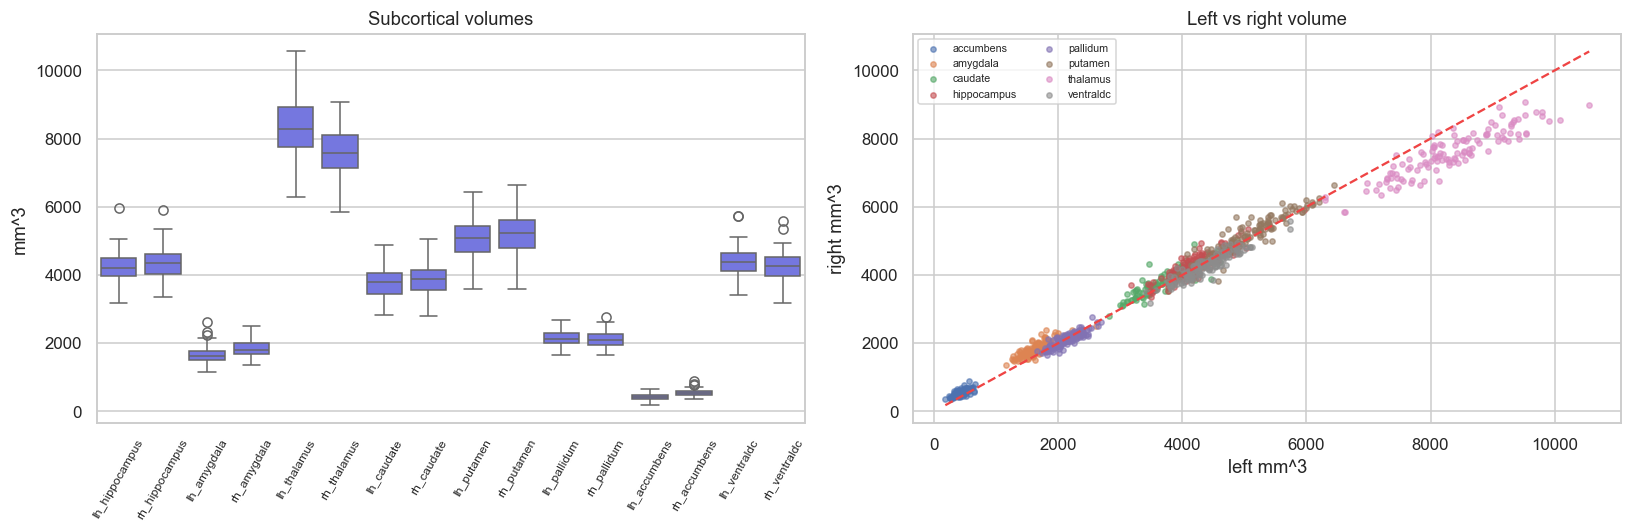

In [2]:
sub = [c for c in morph.columns if c.startswith("fs_vol_")]
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
m = morph[sub].melt(var_name="s", value_name="v"); m["s"]=m["s"].str.replace("fs_vol_","",regex=False)
sns.boxplot(data=m, x="s", y="v", ax=ax[0], color=IND); ax[0].tick_params(axis="x", rotation=60, labelsize=8)
ax[0].set(title="Subcortical volumes", ylabel="mm^3", xlabel="")
structs = sorted(set(c.replace("fs_vol_lh_","").replace("fs_vol_rh_","") for c in sub))
for s in structs:
    l, r = f"fs_vol_lh_{s}", f"fs_vol_rh_{s}"
    if l in morph and r in morph:
        ax[1].scatter(morph[l], morph[r], s=12, alpha=0.6, label=s)
lims=[morph[sub].min().min(), morph[sub].max().max()]
ax[1].plot(lims, lims, color=RED, ls="--"); ax[1].set(title="Left vs right volume", xlabel="left mm^3", ylabel="right mm^3")
ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

### Subcortical volumes on a glass brain (nilearn)
Each subcortical structure at its approximate MNI centroid, coloured by its Spearman correlation with total intelligence and sized by group-mean volume. A spatial read of which deep-brain structures carry morphometric signal.

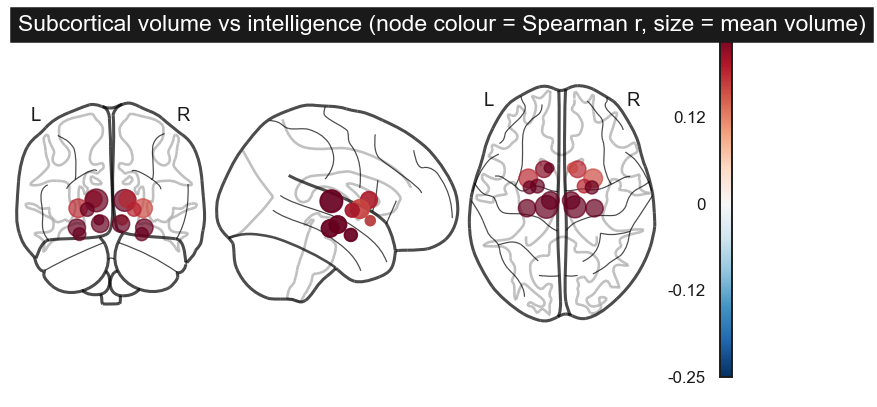

In [3]:
try:
    from nilearn import plotting
    from scipy.stats import spearmanr
    SUB_MNI = {"thalamus":(11,-19,8),"caudate":(13,10,9),"putamen":(25,3,2),"pallidum":(18,-3,1),
               "hippocampus":(26,-20,-13),"amygdala":(24,-4,-18),"accumbens":(9,11,-7),"ventraldc":(8,-14,-10)}
    tgt = target.reindex(morph.index)
    coords, vals, means = [], [], []
    for s,(x,y,z) in SUB_MNI.items():
        for hemi,sgn in (("lh",-1),("rh",1)):
            col=f"fs_vol_{hemi}_{s}"
            if col in morph:
                m=morph[col].notna()&tgt.notna()
                vals.append(spearmanr(morph[col][m], tgt[m]).statistic if m.sum()>20 else 0.0)
                coords.append((sgn*x,y,z)); means.append(float(morph[col].mean()))
    means=np.array(means); sizes=(40+180*(means-means.min())/(np.ptp(means)+1e-9)).tolist()
    plotting.plot_markers(np.array(vals), coords, node_size=sizes, node_cmap="RdBu_r",
                          node_vmin=-0.25, node_vmax=0.25, display_mode="ortho",
                          title="Subcortical volume vs intelligence (node colour = Spearman r, size = mean volume)")
    plt.show()
except Exception as e:
    print("subcortical glass brain skipped:", e)

## 2. Head-size scaling and per-region cortical thickness map

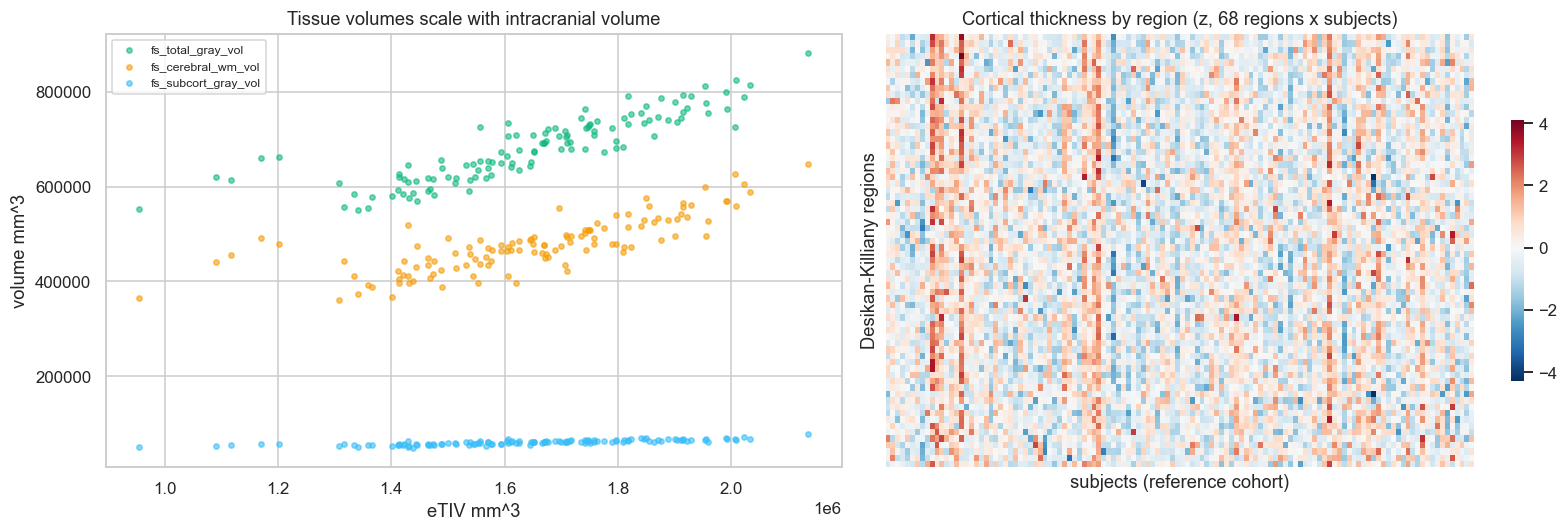

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
if "fs_etiv" in morph:
    for c,col in zip(["fs_total_gray_vol","fs_cerebral_wm_vol","fs_subcort_gray_vol"],[GRN,ORG,BLU]):
        if c in morph: ax[0].scatter(morph["fs_etiv"], morph[c], s=12, alpha=0.6, label=c, color=col)
    ax[0].set(title="Tissue volumes scale with intracranial volume", xlabel="eTIV mm^3", ylabel="volume mm^3"); ax[0].legend(fontsize=8)
thk = [c for c in morph.columns if c.startswith("fs_thk_")]
z = (morph[thk]-morph[thk].mean())/morph[thk].std()
sns.heatmap(z.T, cmap="RdBu_r", center=0, ax=ax[1], cbar_kws={"shrink":.6}, xticklabels=False, yticklabels=False)
ax[1].set(title=f"Cortical thickness by region (z, {len(thk)} regions x subjects)", xlabel="subjects (reference cohort)", ylabel="Desikan-Killiany regions")
plt.tight_layout(); plt.show()

## 3. Morphometry correlation structure and links to intelligence

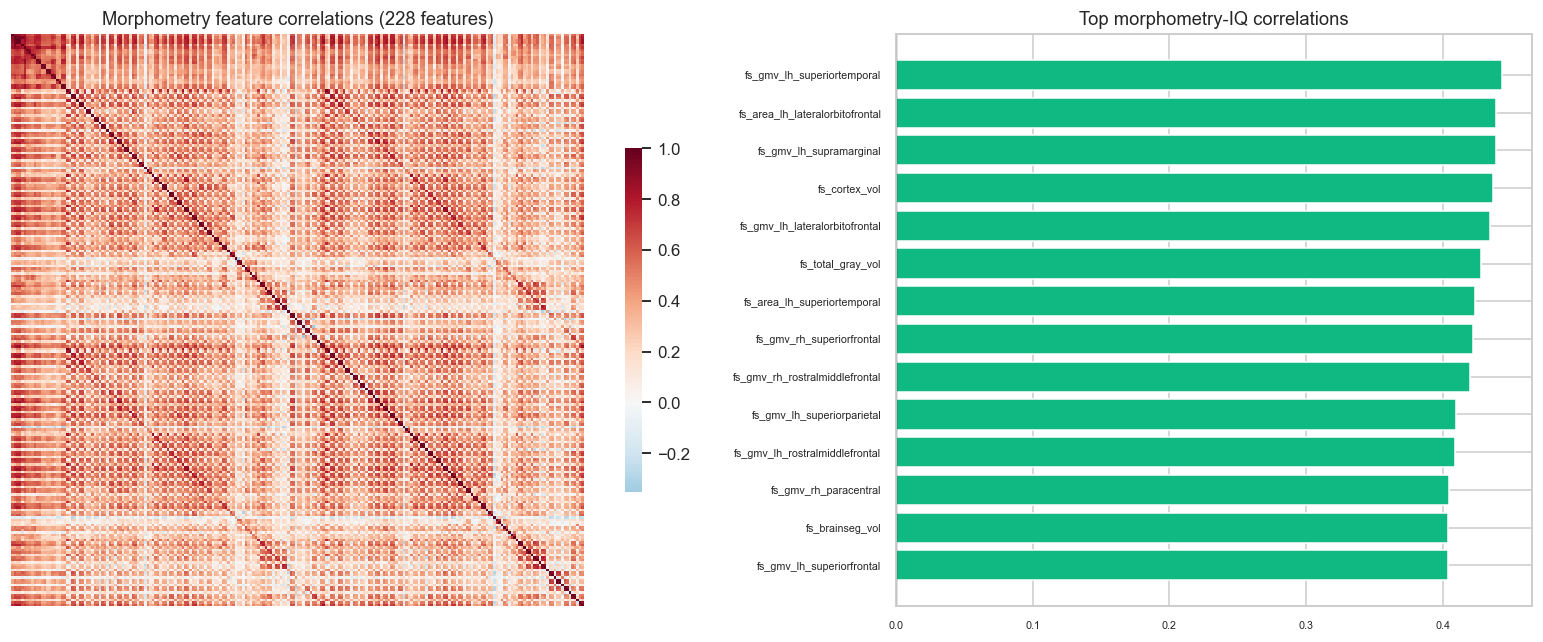

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios":[1.3,1]})
sns.heatmap(morph.corr(), cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink":.6}, ax=ax[0], xticklabels=False, yticklabels=False)
ax[0].set_title(f"Morphometry feature correlations ({morph.shape[1]} features)")
tgt = target.reindex(morph.index)
rows=[]
for c in morph.columns:
    mm = morph[c].notna() & tgt.notna()
    if mm.sum()>30: rows.append((c, float(np.corrcoef(morph[c][mm], tgt[mm])[0,1])))
rho = pd.DataFrame(rows, columns=["f","r"]).sort_values("r")
rho2 = rho.reindex(rho["r"].abs().sort_values(ascending=False).index).head(14).sort_values("r")
ax[1].barh(rho2["f"], rho2["r"], color=[RED if v<0 else GRN for v in rho2["r"]])
ax[1].axvline(0,color="#333"); ax[1].set_title("Top morphometry-IQ correlations"); ax[1].tick_params(labelsize=7)
plt.tight_layout(); plt.show()

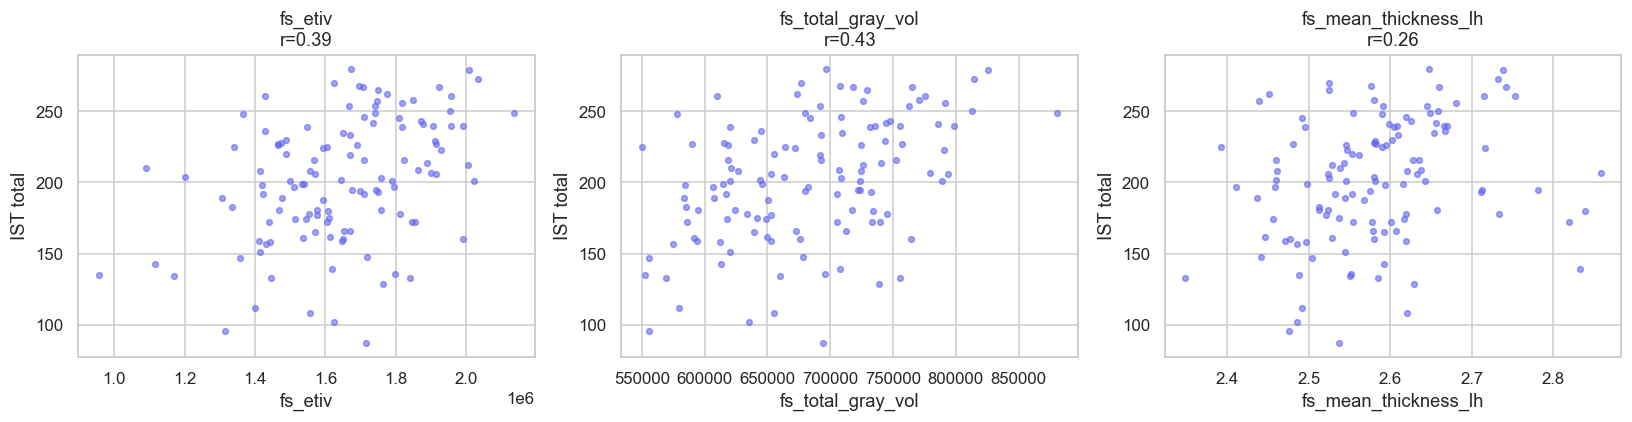

In [6]:
glob = [c for c in ["fs_etiv","fs_total_gray_vol","fs_mean_thickness_lh"] if c in morph]
fig, ax = plt.subplots(1, len(glob), figsize=(5*len(glob), 4))
for a, c in zip(np.atleast_1d(ax), glob):
    mm = morph[c].notna() & tgt.notna()
    a.scatter(morph[c][mm], tgt[mm], s=14, alpha=0.6, color=IND)
    r = np.corrcoef(morph[c][mm], tgt[mm])[0,1]
    a.set(title=f"{c}\nr={r:.2f}", xlabel=c, ylabel="IST total")
plt.tight_layout(); plt.show()

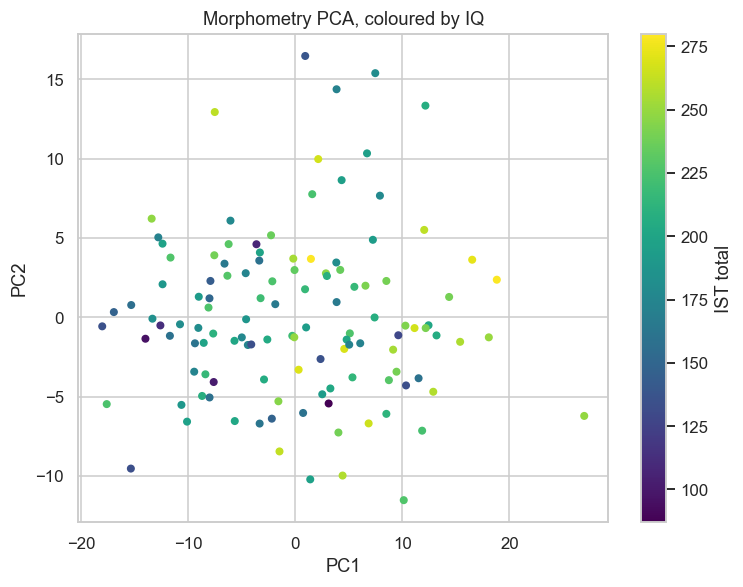

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
Mp = morph.dropna()
if len(Mp) > 10:
    Z2 = PCA(2).fit_transform(StandardScaler().fit_transform(Mp))
    fig, axp = plt.subplots(figsize=(7,5.5))
    sc = axp.scatter(Z2[:,0], Z2[:,1], c=target.reindex(Mp.index), cmap="viridis", s=18)
    plt.colorbar(sc, label="IST total"); axp.set(title="Morphometry PCA, coloured by IQ", xlabel="PC1", ylabel="PC2")
    plt.tight_layout(); plt.show()

## 4. Per-region morphometry mosaic: where each measure tracks intelligence
The high-resolution branch gives thickness, surface area and gray-matter volume for every Desikan-Killiany region. These lobe-grouped mosaics show, per region and hemisphere, the Spearman correlation of each morphometric measure with total intelligence, so spatial patterns are visible at a glance.

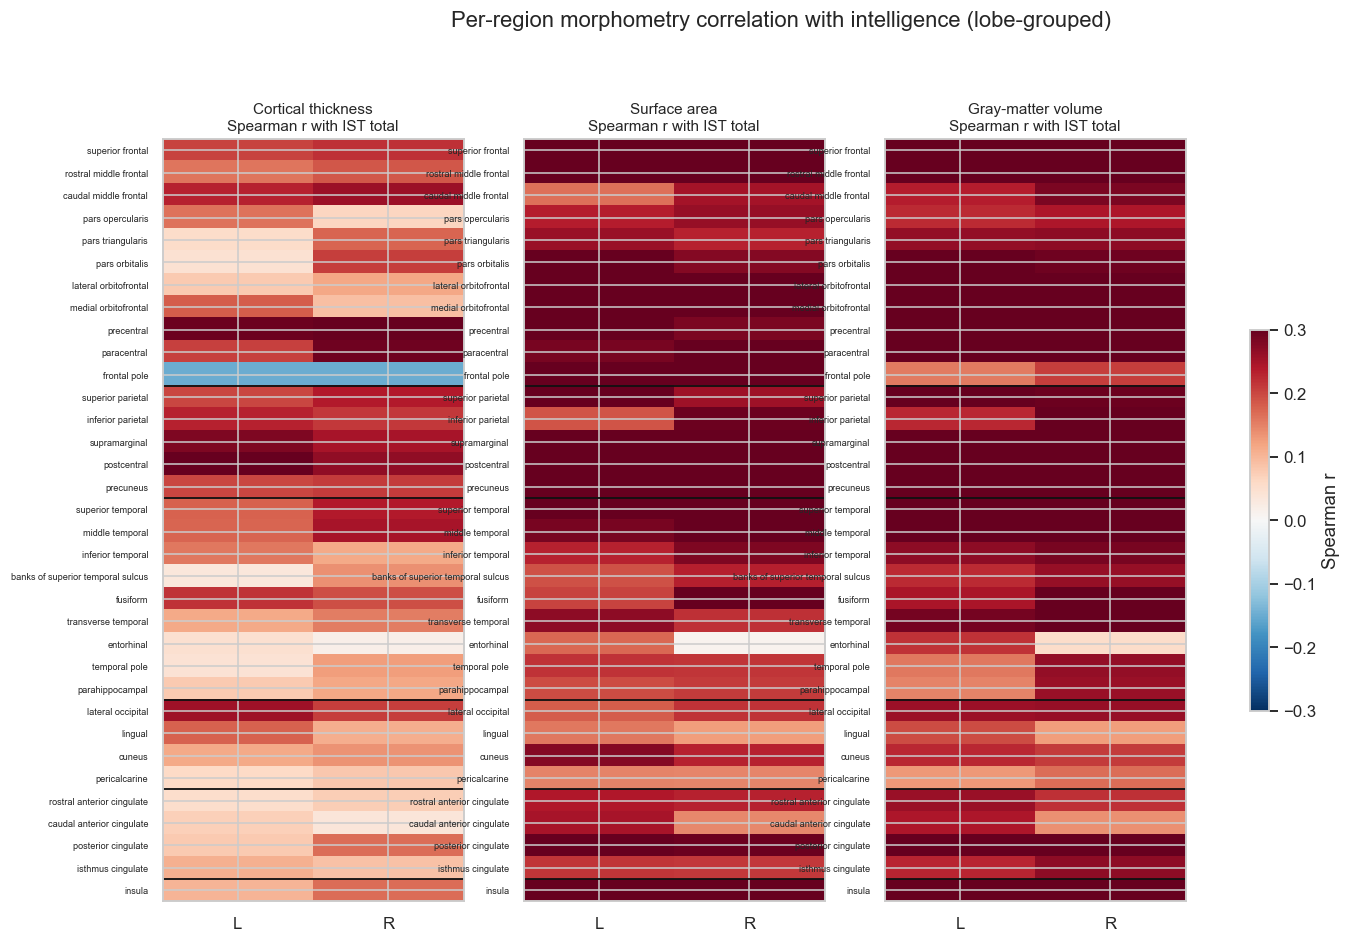

In [8]:
repo = next(p for p in [ROOT,*ROOT.parents] if (p/"src"/"full_stack").is_dir())
sys.path.insert(0, str(repo))
from validation.common.freesurfer import DK_LOBES, LOBES, REGION_LABELS
from scipy.stats import spearmanr
regions = [r for lobe in LOBES for r in DK_LOBES if DK_LOBES[r]==lobe]
lobe_of = [DK_LOBES[r] for r in regions]
measures = [("fs_thk","Cortical thickness"),("fs_area","Surface area"),("fs_gmv","Gray-matter volume")]
tgt = target.reindex(morph.index)
fig, axes = plt.subplots(1, 3, figsize=(15, 9))
for ax,(pref,mtitle) in zip(axes, measures):
    M=[]
    for r in regions:
        row=[]
        for hemi in ("lh","rh"):
            col=f"{pref}_{hemi}_{r}"
            if col in morph:
                m=morph[col].notna()&tgt.notna()
                row.append(spearmanr(morph[col][m], tgt[m]).statistic if m.sum()>20 else np.nan)
            else: row.append(np.nan)
        M.append(row)
    M=np.array(M)
    im=ax.imshow(M, cmap="RdBu_r", vmin=-0.3, vmax=0.3, aspect="auto")
    ax.set_xticks([0,1]); ax.set_xticklabels(["L","R"])
    ax.set_yticks(range(len(regions))); ax.set_yticklabels([REGION_LABELS.get(r,r) for r in regions], fontsize=6)
    # lobe separators
    for i in range(1,len(regions)):
        if lobe_of[i]!=lobe_of[i-1]: ax.axhline(i-0.5, color="#111", lw=1.2)
    ax.set_title(f"{mtitle}\nSpearman r with IST total", fontsize=10)
fig.colorbar(im, ax=axes, shrink=0.5, label="Spearman r")
plt.suptitle("Per-region morphometry correlation with intelligence (lobe-grouped)", y=1.01)
plt.show()

## 5. Functional connectome: network matrices

<Figure size 715x605 with 0 Axes>

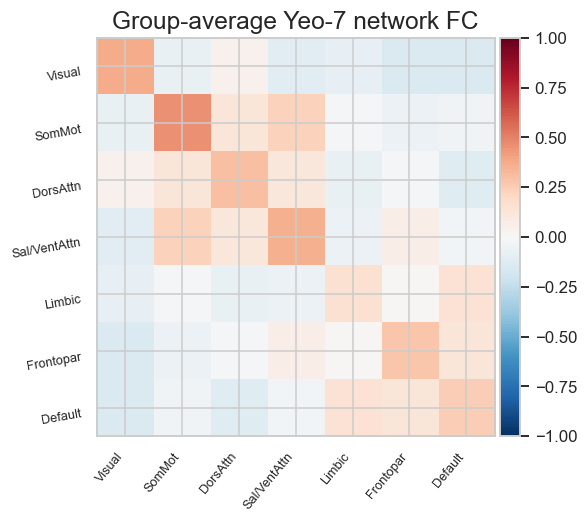

In [9]:
YEO7 = ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]
LBL = ["Visual","SomMot","DorsAttn","Sal/VentAttn","Limbic","Frontopar","Default"]
mats = {p.stem: np.load(p) for p in sorted(fc_dir.glob("*.npy"))}
group = np.nanmean(np.stack(list(mats.values())), axis=0)
fig = plt.figure(figsize=(6.5,5.5))
plotting.plot_matrix(group, labels=LBL, colorbar=True, vmin=-1, vmax=1, title="Group-average Yeo-7 network FC")
plt.show()

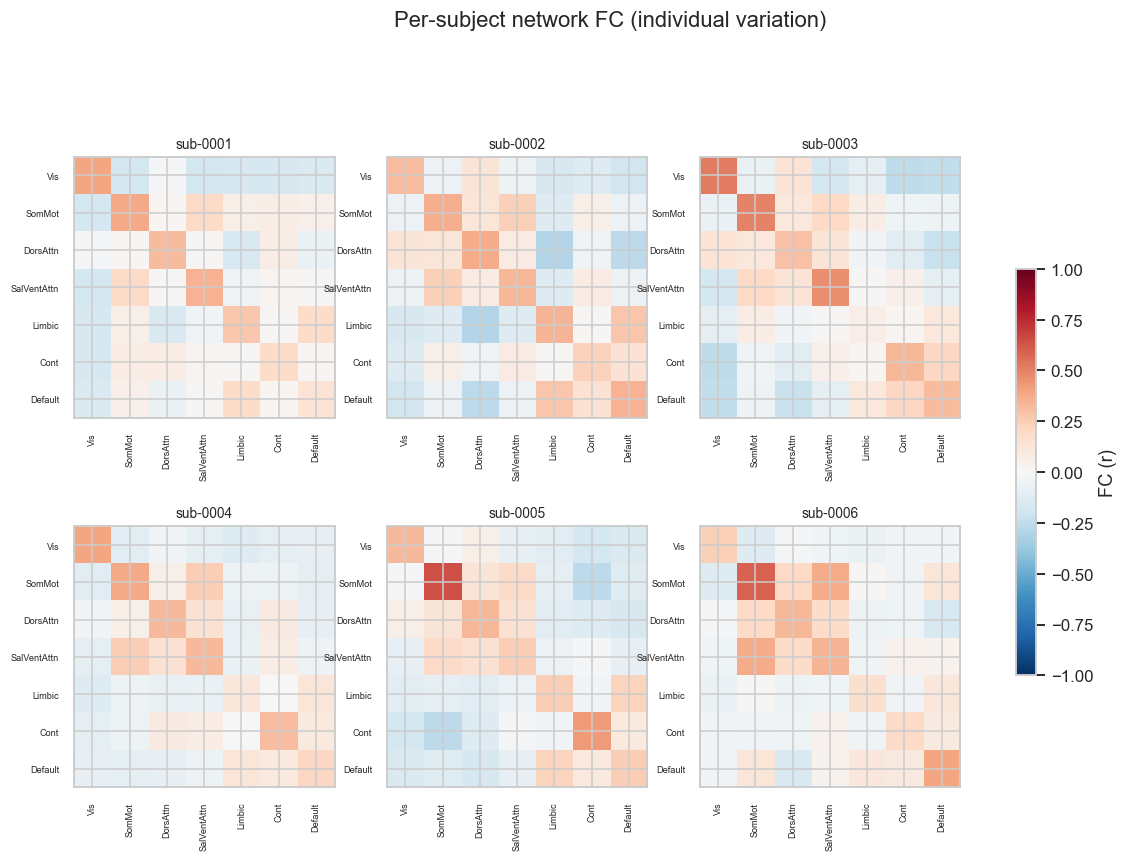

In [10]:
ids = list(mats)[:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, pid in zip(axes.flat, ids):
    im = ax.imshow(mats[pid], vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(pid, fontsize=9); ax.set_xticks(range(7)); ax.set_yticks(range(7))
    ax.set_xticklabels(YEO7, rotation=90, fontsize=6); ax.set_yticklabels(YEO7, fontsize=6)
fig.colorbar(im, ax=axes, shrink=0.6, label="FC (r)")
plt.suptitle("Per-subject network FC (individual variation)", y=1.02); plt.show()

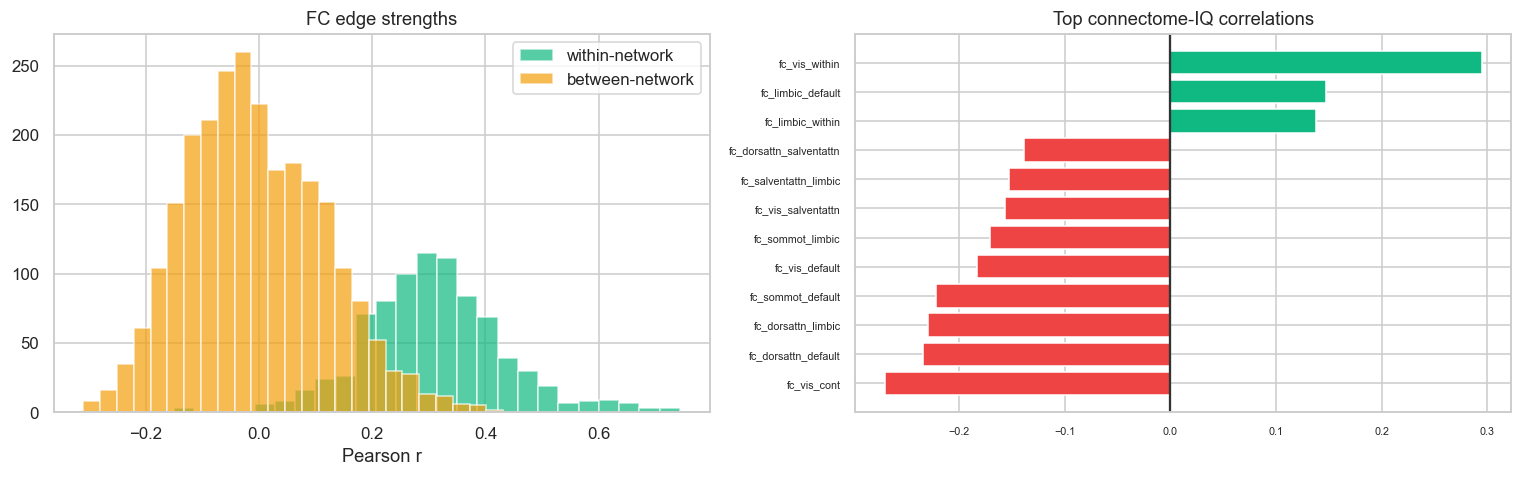

In [11]:
within = [c for c in conn.columns if c.endswith("_within")]
between = [c for c in conn.columns if c not in within]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].hist(conn[within].values.flatten(), bins=25, alpha=0.7, color=GRN, label="within-network")
ax[0].hist(conn[between].values.flatten(), bins=25, alpha=0.7, color=ORG, label="between-network")
ax[0].set(title="FC edge strengths", xlabel="Pearson r"); ax[0].legend()
tgtc = target.reindex(conn.index)
rows=[]
for c in conn.columns:
    mm = conn[c].notna() & tgtc.notna()
    if mm.sum()>15: rows.append((c, float(np.corrcoef(conn[c][mm], tgtc[mm])[0,1])))
rc = pd.DataFrame(rows, columns=["f","r"])
rc = rc.reindex(rc["r"].abs().sort_values(ascending=False).index).head(12).sort_values("r")
ax[1].barh(rc["f"], rc["r"], color=[RED if v<0 else GRN for v in rc["r"]])
ax[1].axvline(0,color="#333"); ax[1].set_title("Top connectome-IQ correlations"); ax[1].tick_params(labelsize=7)
plt.tight_layout(); plt.show()

## 6. High-resolution parcellation and network connectome (nilearn)
First the cortical atlas underlying the connectome: the 100 Schaefer parcels, coloured by their Yeo-7 network, as a mosaic of slices. This is the high-resolution parcellation that the 28 network-level features summarise; re-extracting FC at this parcel level (or a finer Schaefer-200 / 17-network atlas) is a config knob.

[get_dataset_dir] Dataset found in /Users/stijnvanseveren/nilearn_data/schaefer_2018

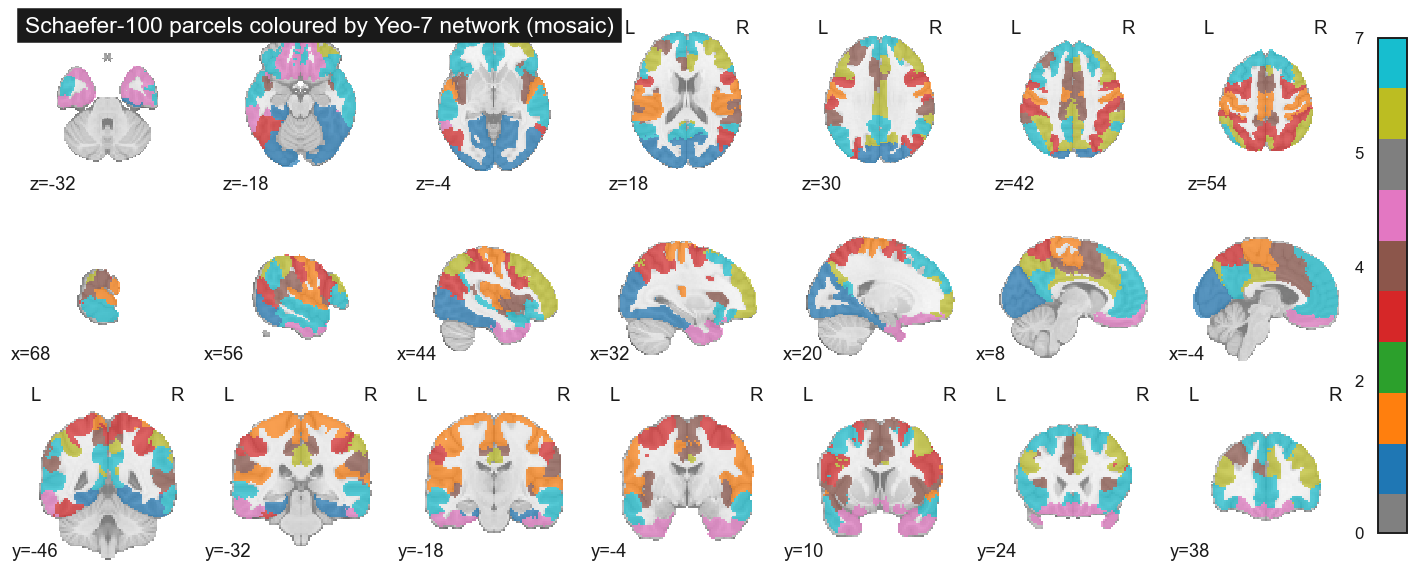

In [12]:
try:
    from nilearn import plotting, image
    from validation.common import connectome as C
    atlas = C.load_atlas(100, 7, 2)
    order = ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]
    net_idx = {a:i+1 for i,a in enumerate(order)}
    lut = np.array([0] + [net_idx.get(n, 0) for n in C.atlas_networks(atlas)])
    maps = image.load_img(atlas.maps)
    net_img = image.new_img_like(maps, lut[maps.get_fdata().astype(int)])
    plotting.plot_roi(net_img, display_mode="mosaic", cmap="tab10", colorbar=True,
                      title="Schaefer-100 parcels coloured by Yeo-7 network (mosaic)")
    plt.show()
except Exception as e:
    print("parcellation mosaic skipped:", e)

The group-average 7-network functional connectivity rendered on a glass brain: each node is a Yeo network placed at the centroid of its Schaefer parcels, each edge a mean between-network correlation. Uses only the small Schaefer atlas (no raw BOLD).

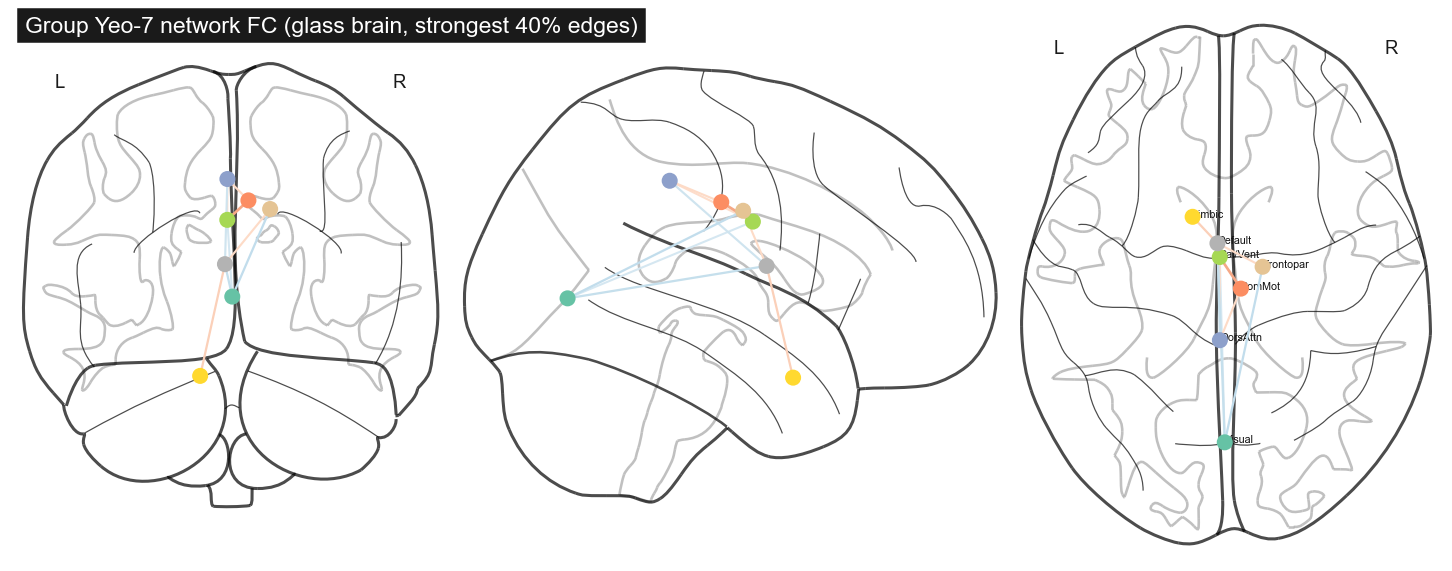

In [13]:
try:
    from nilearn import plotting
    from validation.common import connectome as C
    atlas = C.load_atlas(100, 7, 2)
    nets = np.array(C.atlas_networks(atlas))
    pcoords = np.array(plotting.find_parcellation_cut_coords(atlas.maps))
    order = ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]
    ncoords = np.array([pcoords[nets==a].mean(axis=0) for a in order])
    node_labels = ["Visual","SomMot","DorsAttn","Sal/Vent","Limbic","Frontopar","Default"]
    fig = plt.figure(figsize=(13,5))
    disp = plotting.plot_connectome(group, ncoords, node_size=90, edge_threshold="60%",
                                    edge_vmin=-0.6, edge_vmax=0.6, edge_cmap="RdBu_r",
                                    title="Group Yeo-7 network FC (glass brain, strongest 40% edges)",
                                    figure=fig)
    for (x,y,z), lab in zip(ncoords, node_labels):
        disp.axes['z'].ax.text(x, y, lab, fontsize=7, color="#111")
    plt.show()
except Exception as e:
    print("network glass brain skipped:", e)

## 7. Parcel-level connectome and glass brain (one subject)
This optional view reconstructs the full 100x100 parcel FC from the raw movie-watching BOLD. The BOLD is not cached (only the reduced 7x7 network matrices are), so it runs only if the file is already present locally; otherwise it is skipped with a note. Re-extracting at a finer atlas (e.g. 17 Yeo sub-networks) is a config knob in `validation/common/connectome.py`.

In [14]:
repo = next(p for p in [ROOT,*ROOT.parents] if (p/"src"/"full_stack").is_dir())
sys.path.insert(0, str(repo))
from validation.common import connectome as C
sub = list(mats)[0]
cache = ROOT/"brain"/"_cache"/"connectome"
space = "space-MNI152NLin2009cAsym"
bold_cached = (cache / f"{sub}_task-moviewatching_{space}_desc-preproc_bold.nii.gz").exists()
if bold_cached:
    atlas = C.load_atlas(100,7,2); coords = plotting.find_parcellation_cut_coords(atlas.maps)
    paths = C.download_func(sub, "ds003097", cache)
    ts = C.parcel_timeseries(paths, atlas); pfc = np.corrcoef(ts.T)
    fig, ax = plt.subplots(figsize=(6.5,5.5))
    im = ax.imshow(pfc, vmin=-1, vmax=1, cmap="RdBu_r"); ax.set_title(f"Parcel-level FC 100x100 ({sub})")
    plt.colorbar(im, label="r"); plt.tight_layout(); plt.show()
    plotting.plot_connectome(pfc, coords, edge_threshold="99.3%", node_size=16,
                             title=f"Movie-watching FC glass brain ({sub}, top 0.7% edges)")
    plt.show()
else:
    print(f"Raw BOLD for {sub} not cached; skipping parcel-level reconstruction.")
    print("To enable: run validation.common.connectome.download_func for one subject, then re-run.")

Raw BOLD for sub-0001 not cached; skipping parcel-level reconstruction.
To enable: run validation.common.connectome.download_func for one subject, then re-run.


Naturalistic-viewing connectivity varies clearly between individuals; the engine receives the compact 28-value network summary, while these parcel-level views are for inspection. Morphometry and connectomics both nest under the single Brain domain.